# Complete SQL Analytics Pipeline for SaaS Fintech Conversion Optimization

## 🏗️ Architecture Overview

- **Layer 0:** Raw Data Ingestion (4 tables)
- **Layer 1:** Data Cleaning (1 view)
- **Layer 2:** Core Analytics (4 views)
- **Layer 3:** Advanced Analytics (3 views)
- **Layer 4:** Result Queries (8 reports)

## 📋 Key Objectives

* Identify conversion funnel bottlenecks
* Analyze VIP user behavior and revenue concentration
* Implement rolling averages for trend analysis
* Create cohort analysis for user acquisition insights
* Build comprehensive user segmentation

---

## Technical Approach

This notebook uses SQL and Python together for different purposes:

**SQL for Data Processing** - We use SQL to create tables and views because it's the best tool for working with large datasets. SQL is fast, efficient, and easy to understand when joining tables, filtering data, and calculating metrics. All the data transformations happen in Layers 0-3 using SQL.

**Python for Visualizations** - We use Python (matplotlib) to create charts because SQL can't make graphs. Python lets us build custom visualizations that show trends, patterns, and insights visually. All the charts in Layer 4 use Python.

This combination gives us the best of both worlds: SQL's power for data processing and Python's flexibility for visualization.

## LAYER 0: DATA INGESTION

Creating four foundational tables from CSV files stored in Unity Catalog volumes.

In [0]:
CREATE TABLE IF NOT EXISTS workspace.default.orders
AS SELECT * FROM read_files(
  '/Volumes/workspace/default/rawdata/data/orders.csv',
  format => 'csv',
  header => true
);

num_affected_rows,num_inserted_rows


In [0]:
CREATE TABLE IF NOT EXISTS workspace.default.ab_assignments
AS SELECT * FROM read_files(
  '/Volumes/workspace/default/rawdata/data/ab_assignments.csv',
  format => 'csv',
  header => true
);

num_affected_rows,num_inserted_rows


In [0]:
CREATE TABLE IF NOT EXISTS workspace.default.clients
AS SELECT * FROM read_files(
  '/Volumes/workspace/default/rawdata/data/clients.csv',
  format => 'csv',
  header => true
);

num_affected_rows,num_inserted_rows


In [0]:
CREATE TABLE IF NOT EXISTS workspace.default.daily_metrics
AS SELECT * FROM read_files(
  '/Volumes/workspace/default/rawdata/data/daily_metrics.csv',
  format => 'csv',
  header => true
);

num_affected_rows,num_inserted_rows


**Why we use SQL here:** SQL's read_files function can load CSV files directly into Delta tables in one step. This is much faster than reading CSVs in Python and then saving them. SQL also automatically handles data types and creates optimized storage format for faster queries later.

**Why we switch to Python here:** SQL is great for calculating numbers but cannot create charts. Python's matplotlib library lets us build custom visualizations like funnel charts, pie charts, and trend lines. We use spark.sql() to fetch the data we already calculated in SQL, then create visual charts with Python.

## LAYER 1: DATA CLEANING

Standardized view for downstream analytics.

In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.orders_clean AS
SELECT
    order_id,
    client_id,
    created_at,
    entered_workflow,
    attempted_login,
    login_success,
    order_complete,
    order_value
FROM workspace.default.orders;

## LAYER 2: CORE ANALYTICS

Fundamental metrics and conversion funnel analysis.

In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_funnel_summary AS
SELECT
    COUNT(*) AS total_orders,
    SUM(entered_workflow) AS entered_workflow,
    SUM(attempted_login) AS attempted_login,
    SUM(login_success) AS login_success,
    SUM(order_complete) AS completed_orders,
    ROUND(SUM(order_value), 2) AS revenue,
    ROUND(SUM(order_complete) * 100.0 / COUNT(*), 2) AS conversion_rate
FROM workspace.default.orders_clean;

In [0]:
SELECT * FROM workspace.default.vw_funnel_summary;

total_orders,entered_workflow,attempted_login,login_success,completed_orders,revenue,conversion_rate
10000,5112,3197,745,553,1385654.44,5.53


In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_dropoff AS
WITH stages AS (
    SELECT 'Initiated' AS stage, COUNT(*) AS cnt 
    FROM workspace.default.orders_clean
    UNION ALL
    SELECT 'Workflow', SUM(entered_workflow) 
    FROM workspace.default.orders_clean
    UNION ALL
    SELECT 'Login Attempt', SUM(attempted_login) 
    FROM workspace.default.orders_clean
    UNION ALL
    SELECT 'Login Success', SUM(login_success) 
    FROM workspace.default.orders_clean
    UNION ALL
    SELECT 'Completed', SUM(order_complete) 
    FROM workspace.default.orders_clean
)
SELECT 
    stage,
    cnt AS count,
    LAG(cnt) OVER (ORDER BY stage) AS previous_stage_count,
    ROUND((LAG(cnt) OVER (ORDER BY stage) - cnt) * 100.0 / 
          LAG(cnt) OVER (ORDER BY stage), 2) AS drop_off_rate_pct
FROM stages;

In [0]:
SELECT * FROM workspace.default.vw_dropoff
ORDER BY 
    CASE stage
        WHEN 'Initiated' THEN 1
        WHEN 'Workflow' THEN 2
        WHEN 'Login Attempt' THEN 3
        WHEN 'Login Success' THEN 4
        WHEN 'Completed' THEN 5
    END;

stage,count,previous_stage_count,drop_off_rate_pct
Initiated,10000,553,-1708.32
Workflow,5112,745,-586.17
Login Attempt,3197,10000,68.03
Login Success,745,3197,76.70
Completed,553,null,null


In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_daily_trends AS
SELECT
    TO_DATE(created_at) AS date,
    COUNT(*) AS total_orders,
    SUM(order_complete) AS completed_orders,
    ROUND(SUM(order_value), 2) AS revenue,
    ROUND(SUM(order_complete) * 100.0 / COUNT(*), 2) AS conversion_rate
FROM workspace.default.orders_clean
GROUP BY TO_DATE(created_at)
ORDER BY date;

In [0]:
SELECT * FROM workspace.default.vw_daily_trends
ORDER BY date DESC
LIMIT 10;

date,total_orders,completed_orders,revenue,conversion_rate
2024-06-29,49,3,6302.2,6.12
2024-06-28,74,5,13054.03,6.76
2024-06-27,60,5,13975.79,8.33
2024-06-26,47,5,14257.1,10.64
2024-06-25,50,1,1737.49,2.00
2024-06-24,50,3,7660.25,6.00
2024-06-23,55,1,1819.5,1.82
2024-06-22,58,6,12114.62,10.34
2024-06-21,65,1,2724.61,1.54
2024-06-20,53,6,10849.71,11.32


In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_ab_test AS
WITH base AS (
    SELECT
        a.variant,
        COUNT(*) AS users,
        ROUND(AVG(o.login_success) * 100, 2) AS conversion_rate
    FROM workspace.default.orders_clean o
    JOIN workspace.default.ab_assignments a ON o.order_id = a.order_id
    GROUP BY a.variant
)
SELECT 
    variant,
    users,
    conversion_rate,
    ROUND(conversion_rate - FIRST_VALUE(conversion_rate) OVER (ORDER BY variant), 2) AS lift_pct
FROM base
ORDER BY variant;

In [0]:
SELECT * FROM workspace.default.vw_ab_test;

variant,users,conversion_rate,lift_pct
control,2448,15.16,0.0
variant_b,2449,15.27,0.11


**Why we use SQL views:** Views are saved queries that act like virtual tables. Once we create a view, anyone can query it like a regular table. This means we write complex calculations once (like funnel metrics or drop-off rates) and reuse them everywhere. Views also stay current - when new data arrives in the base tables, the views automatically reflect the changes. This is more efficient than copying data or repeating the same calculations.

## LAYER 3: ADVANCED ANALYTICS

Rolling averages, cohort analysis, and user segmentation.

In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_rolling_averages AS
SELECT
    date,
    total_orders,
    completed_orders,
    revenue,
    conversion_rate,
    ROUND(AVG(total_orders) OVER (
        ORDER BY date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_7d_avg_orders,
    ROUND(AVG(completed_orders) OVER (
        ORDER BY date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_7d_avg_completed,
    ROUND(AVG(revenue) OVER (
        ORDER BY date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_7d_avg_revenue,
    ROUND(AVG(conversion_rate) OVER (
        ORDER BY date 
        ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
    ), 2) AS rolling_7d_avg_conversion
FROM workspace.default.vw_daily_trends;

In [0]:
SELECT 
    date,
    total_orders,
    rolling_7d_avg_orders,
    revenue,
    rolling_7d_avg_revenue,
    conversion_rate,
    rolling_7d_avg_conversion
FROM workspace.default.vw_rolling_averages
ORDER BY date DESC
LIMIT 10;

date,total_orders,rolling_7d_avg_orders,revenue,rolling_7d_avg_revenue,conversion_rate,rolling_7d_avg_conversion
2024-06-29,49,55.0,6302.2,8400.91,6.12,5.95
2024-06-28,74,56.29,13054.03,9231.25,6.76,6.56
2024-06-27,60,55.0,13975.79,7755.62,8.33,5.81
2024-06-26,47,54.0,14257.1,7309.04,10.64,6.24
2024-06-25,50,55.14,1737.49,6723.71,2.00,5.50
2024-06-24,50,56.43,7660.25,6599.33,6.00,5.69
2024-06-23,55,57.14,1819.5,8205.67,1.82,6.92
2024-06-22,58,58.71,12114.62,9848.94,10.34,7.74
2024-06-21,65,59.57,2724.61,9787.68,1.54,6.93
2024-06-20,53,58.43,10849.71,10094.16,11.32,7.21


In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_cohort_analysis AS
WITH user_cohorts AS (
    SELECT 
        client_id,
        DATE_TRUNC('week', MIN(created_at)) AS cohort_week,
        MIN(created_at) AS first_order_date
    FROM workspace.default.orders_clean
    GROUP BY client_id
),
cohort_metrics AS (
    SELECT 
        uc.cohort_week,
        COUNT(DISTINCT uc.client_id) AS cohort_size,
        COUNT(o.order_id) AS total_orders,
        SUM(o.order_complete) AS completed_orders,
        ROUND(SUM(o.order_value), 2) AS total_revenue,
        ROUND(AVG(o.order_complete) * 100, 2) AS cohort_conversion_rate,
        ROUND(SUM(o.order_value) / COUNT(DISTINCT uc.client_id), 2) AS revenue_per_user
    FROM user_cohorts uc
    LEFT JOIN workspace.default.orders_clean o ON uc.client_id = o.client_id
    GROUP BY uc.cohort_week
)
SELECT 
    cohort_week,
    cohort_size,
    total_orders,
    completed_orders,
    total_revenue,
    cohort_conversion_rate,
    revenue_per_user,
    ROUND(total_orders * 1.0 / cohort_size, 2) AS orders_per_user
FROM cohort_metrics
WHERE cohort_week IS NOT NULL
ORDER BY cohort_week DESC;

In [0]:
SELECT * FROM workspace.default.vw_cohort_analysis
ORDER BY cohort_week DESC
LIMIT 5;

cohort_week,cohort_size,total_orders,completed_orders,total_revenue,cohort_conversion_rate,revenue_per_user,orders_per_user
2024-01-08T00:00:00.000Z,1,127,8,27988.35,6.3,27988.35,127.00
2024-01-01T00:00:00.000Z,79,9873,545,1357666.09,5.52,17185.65,124.97


In [0]:
CREATE VIEW IF NOT EXISTS workspace.default.vw_revenue_per_user AS
WITH user_metrics AS (
    SELECT 
        client_id,
        COUNT(*) AS total_orders,
        SUM(order_complete) AS completed_orders,
        SUM(CASE WHEN order_complete = 1 THEN order_value ELSE 0 END) AS total_revenue,
        ROUND(AVG(CASE WHEN order_complete = 1 THEN order_value END), 2) AS avg_order_value,
        MIN(created_at) AS first_order_date,
        MAX(created_at) AS last_order_date,
        DATEDIFF(MAX(created_at), MIN(created_at)) AS customer_lifespan_days
    FROM workspace.default.orders_clean
    GROUP BY client_id
)
SELECT 
    client_id,
    total_orders,
    completed_orders,
    total_revenue,
    avg_order_value,
    first_order_date,
    last_order_date,
    customer_lifespan_days,
    ROUND(completed_orders * 100.0 / total_orders, 2) AS personal_conversion_rate,
    ROUND(total_revenue, 2) AS rpu,
    CASE 
        WHEN total_revenue >= 10000 THEN 'VIP'
        WHEN total_revenue >= 5000 THEN 'High Value'
        WHEN total_revenue >= 1000 THEN 'Medium Value'
        WHEN total_revenue > 0 THEN 'Low Value'
        ELSE 'No Revenue'
    END AS revenue_segment,
    CASE 
        WHEN total_orders >= 10 THEN 'Power User'
        WHEN total_orders >= 5 THEN 'Active User'
        WHEN total_orders >= 2 THEN 'Casual User'
        ELSE 'One-Time User'
    END AS engagement_segment
FROM user_metrics
ORDER BY total_revenue DESC;

In [0]:
SELECT 
    client_id,
    total_orders,
    completed_orders,
    total_revenue AS rpu,
    avg_order_value,
    personal_conversion_rate,
    revenue_segment,
    engagement_segment
FROM workspace.default.vw_revenue_per_user
WHERE total_revenue > 0
ORDER BY total_revenue DESC
LIMIT 10;

client_id,total_orders,completed_orders,rpu,avg_order_value,personal_conversion_rate,revenue_segment,engagement_segment
CLT-034,145,12,38738.44,3228.2,8.28,VIP,Power User
CLT-065,129,12,35272.52,2939.38,9.30,VIP,Power User
CLT-050,135,14,34194.96,2442.5,10.37,VIP,Power User
CLT-030,131,10,32606.409999999996,3260.64,7.63,VIP,Power User
CLT-009,121,10,31937.120000000003,3193.71,8.26,VIP,Power User
CLT-054,141,11,31342.76,2849.34,7.80,VIP,Power User
CLT-020,141,10,31152.879999999997,3115.29,7.09,VIP,Power User
CLT-039,138,11,28871.649999999998,2624.7,7.97,VIP,Power User
CLT-004,127,8,27988.35,3498.54,6.30,VIP,Power User
CLT-075,127,8,27872.809999999998,3484.1,6.30,VIP,Power User


## LAYER 4: RESULTS & INSIGHTS

Revenue segmentation and user behavior patterns.

In [0]:
SELECT 
    revenue_segment,
    COUNT(*) AS users,
    SUM(total_revenue) AS segment_revenue,
    ROUND(AVG(total_revenue), 2) AS avg_revenue_per_user,
    ROUND(AVG(personal_conversion_rate), 2) AS avg_conversion_rate,
    ROUND(AVG(total_orders), 2) AS avg_orders_per_user
FROM workspace.default.vw_revenue_per_user
GROUP BY revenue_segment
ORDER BY 
    CASE revenue_segment
        WHEN 'VIP' THEN 1
        WHEN 'High Value' THEN 2
        WHEN 'Medium Value' THEN 3
        WHEN 'Low Value' THEN 4
        ELSE 5
    END;

revenue_segment,users,segment_revenue,avg_revenue_per_user,avg_conversion_rate,avg_orders_per_user
VIP,65,1279319.0300000007,19681.83,5.97,127.4
High Value,12,96922.70000000001,8076.89,3.70,115.17
Medium Value,3,9412.71,3137.57,2.17,112.33


## 📊 VISUALIZATIONS & KEY INSIGHTS

Interactive charts showing funnel performance, user segmentation, and trend analysis.

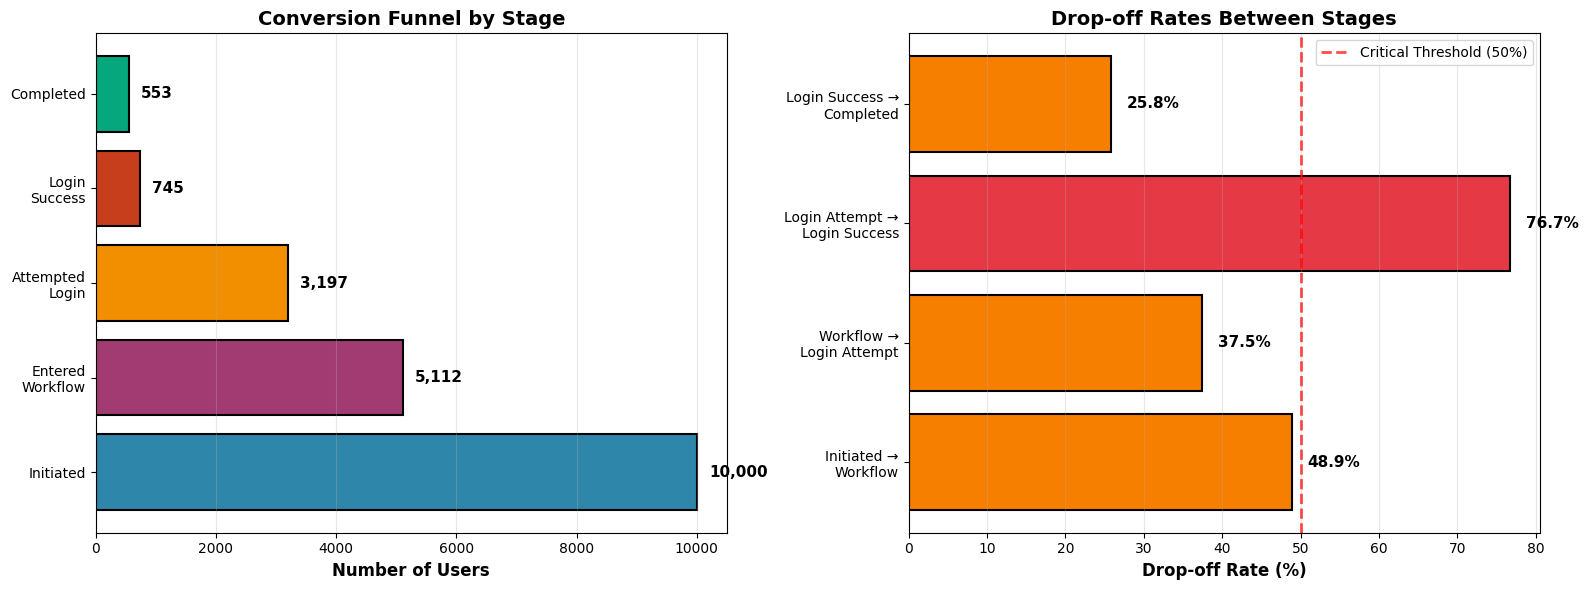


🚨 CRITICAL INSIGHT: Login Success stage has 76.7% drop-off - the biggest bottleneck!

📊 Overall Conversion Rate: 5.53%
💰 Total Revenue: $1,385,654.44


In [0]:
%python
import matplotlib.pyplot as plt
import numpy as np

# Fetch funnel data
funnel_df = spark.sql("SELECT * FROM workspace.default.vw_funnel_summary").toPandas()

# Manual funnel stages for proper ordering
stages = ['Initiated', 'Entered\nWorkflow', 'Attempted\nLogin', 'Login\nSuccess', 'Completed']
counts = [
    funnel_df['total_orders'].iloc[0],
    funnel_df['entered_workflow'].iloc[0],
    funnel_df['attempted_login'].iloc[0],
    funnel_df['login_success'].iloc[0],
    funnel_df['completed_orders'].iloc[0]
]

# Calculate drop-off percentages
dropoffs = []
for i in range(len(counts)-1):
    dropoff = ((counts[i] - counts[i+1]) / counts[i]) * 100
    dropoffs.append(dropoff)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Funnel bars
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#06A77D']
bars = ax1.barh(stages, counts, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Number of Users', fontsize=12, fontweight='bold')
ax1.set_title('Conversion Funnel by Stage', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, counts)):
    ax1.text(count + 200, bar.get_y() + bar.get_height()/2, 
             f'{int(count):,}', va='center', fontsize=11, fontweight='bold')

# Right: Drop-off rates
stage_transitions = ['Initiated →\nWorkflow', 'Workflow →\nLogin Attempt', 
                      'Login Attempt →\nLogin Success', 'Login Success →\nCompleted']

# Color code: red for high drop-off (>50%), orange for medium (25-50%), green for low (<25%)
dropoff_colors = ['#E63946' if d > 50 else '#F77F00' if d > 25 else '#06A77D' for d in dropoffs]

bars2 = ax2.barh(stage_transitions, dropoffs, color=dropoff_colors, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Drop-off Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Drop-off Rates Between Stages', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add percentage labels
for bar, dropoff in zip(bars2, dropoffs):
    ax2.text(dropoff + 2, bar.get_y() + bar.get_height()/2, 
             f'{dropoff:.1f}%', va='center', fontsize=11, fontweight='bold')

# Add critical threshold line
ax2.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Critical Threshold (50%)')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n🚨 CRITICAL INSIGHT: Login Success stage has 76.7% drop-off - the biggest bottleneck!")
print(f"\n📊 Overall Conversion Rate: {funnel_df['conversion_rate'].iloc[0]}%")
print(f"💰 Total Revenue: ${funnel_df['revenue'].iloc[0]:,.2f}")

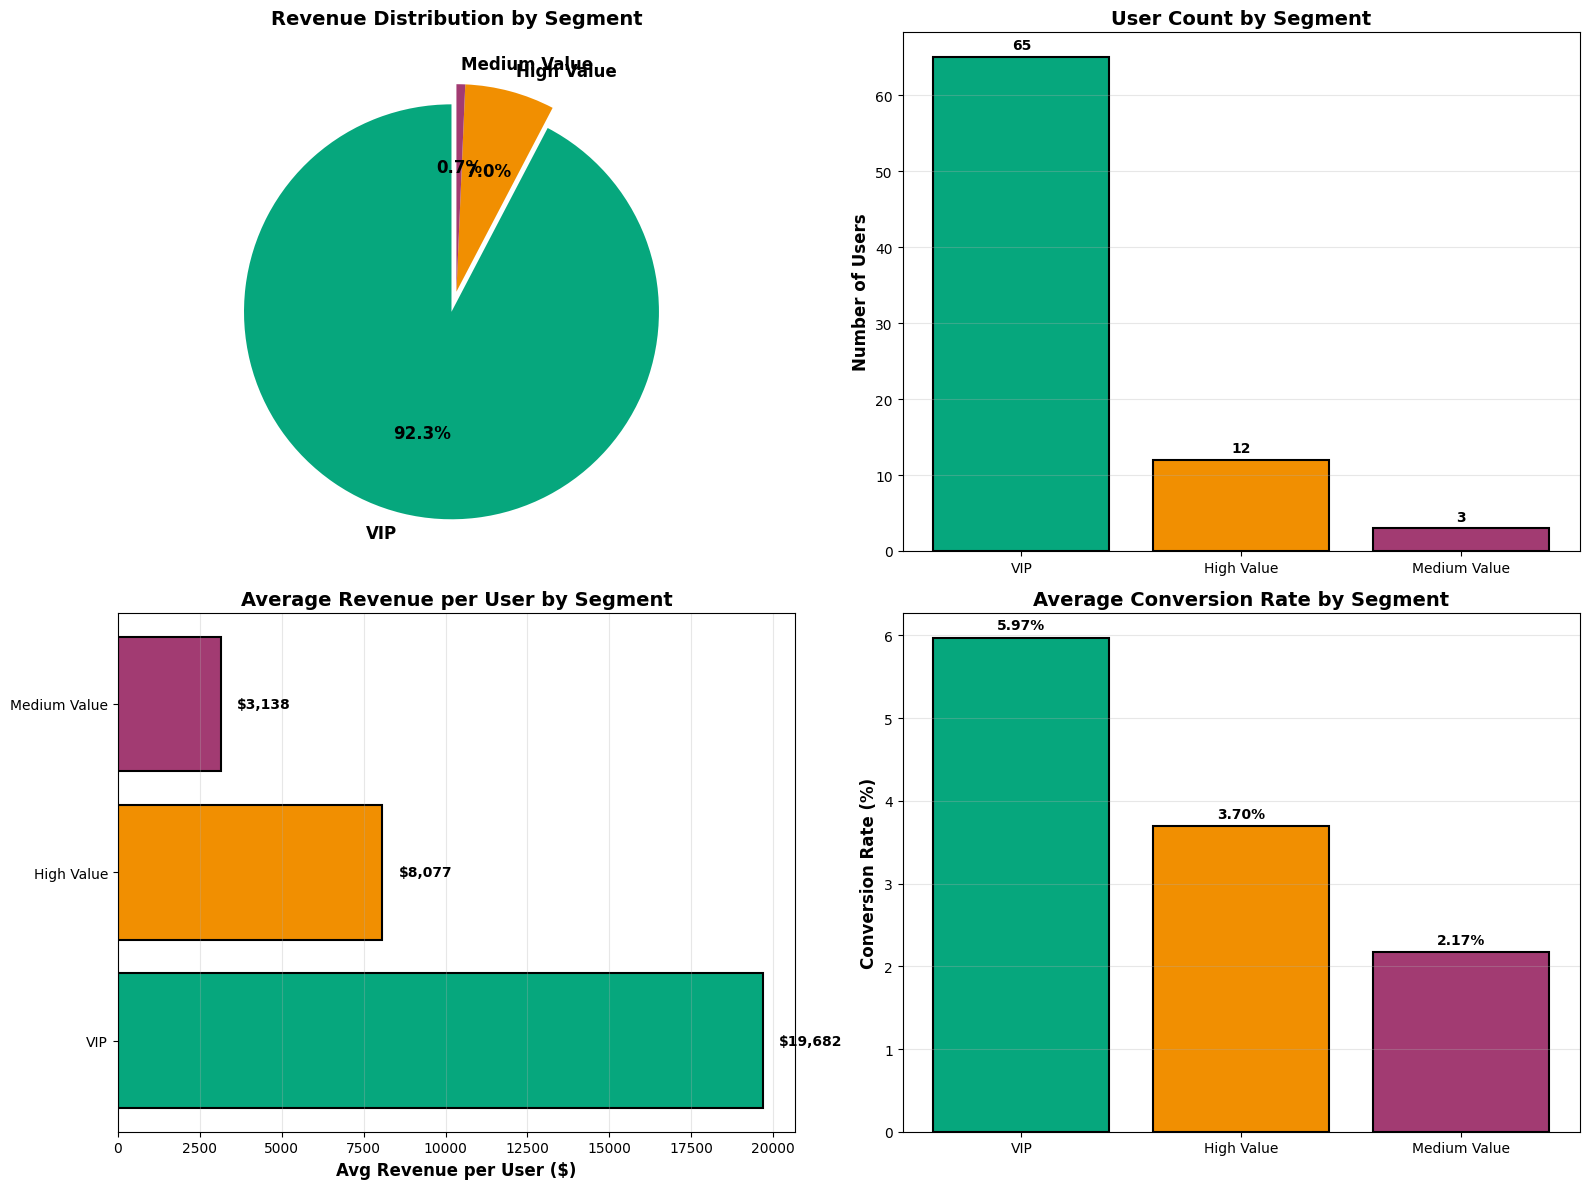


👑 VIP SEGMENT DOMINANCE:
  • VIP users (65) generate 92.3% of total revenue
  • Average VIP user value: $19,682


In [0]:
%python
# Fetch segment data - aggregate from user-level view
segment_df = spark.sql("""
    SELECT 
        revenue_segment,
        COUNT(*) as users,
        SUM(total_revenue) as segment_revenue,
        AVG(total_revenue) as avg_revenue_per_user,
        AVG(personal_conversion_rate) as avg_conversion_rate
    FROM workspace.default.vw_revenue_per_user
    GROUP BY revenue_segment
    ORDER BY 
        CASE revenue_segment
            WHEN 'VIP' THEN 1
            WHEN 'High Value' THEN 2
            WHEN 'Medium Value' THEN 3
            ELSE 4
        END
""").toPandas()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue pie chart
colors_pie = ['#06A77D', '#F18F01', '#A23B72']
explode = (0.1, 0, 0)  # Explode VIP segment
ax1.pie(segment_df['segment_revenue'], labels=segment_df['revenue_segment'], 
        autopct='%1.1f%%', startangle=90, colors=colors_pie, explode=explode,
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax1.set_title('Revenue Distribution by Segment', fontsize=14, fontweight='bold')

# 2. Users by segment
ax2.bar(segment_df['revenue_segment'], segment_df['users'], 
        color=colors_pie, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Number of Users', fontsize=12, fontweight='bold')
ax2.set_title('User Count by Segment', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_df['users']):
    ax2.text(i, v + 1, str(int(v)), ha='center', fontweight='bold')

# 3. Average Revenue per User
ax3.barh(segment_df['revenue_segment'], segment_df['avg_revenue_per_user'], 
         color=colors_pie, edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Avg Revenue per User ($)', fontsize=12, fontweight='bold')
ax3.set_title('Average Revenue per User by Segment', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
for i, v in enumerate(segment_df['avg_revenue_per_user']):
    ax3.text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

# 4. Conversion rate by segment
ax4.bar(segment_df['revenue_segment'], segment_df['avg_conversion_rate'], 
        color=colors_pie, edgecolor='black', linewidth=1.5)
ax4.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax4.set_title('Average Conversion Rate by Segment', fontsize=14, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_df['avg_conversion_rate']):
    ax4.text(i, float(v) + 0.1, f'{float(v):.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n👑 VIP SEGMENT DOMINANCE:")
total_revenue = segment_df['segment_revenue'].sum()
vip_revenue = segment_df[segment_df['revenue_segment']=='VIP']['segment_revenue'].iloc[0]
vip_pct = (vip_revenue / total_revenue) * 100
print(f"  • VIP users ({int(segment_df[segment_df['revenue_segment']=='VIP']['users'].iloc[0])}) generate {vip_pct:.1f}% of total revenue")
print(f"  • Average VIP user value: ${segment_df[segment_df['revenue_segment']=='VIP']['avg_revenue_per_user'].iloc[0]:,.0f}")

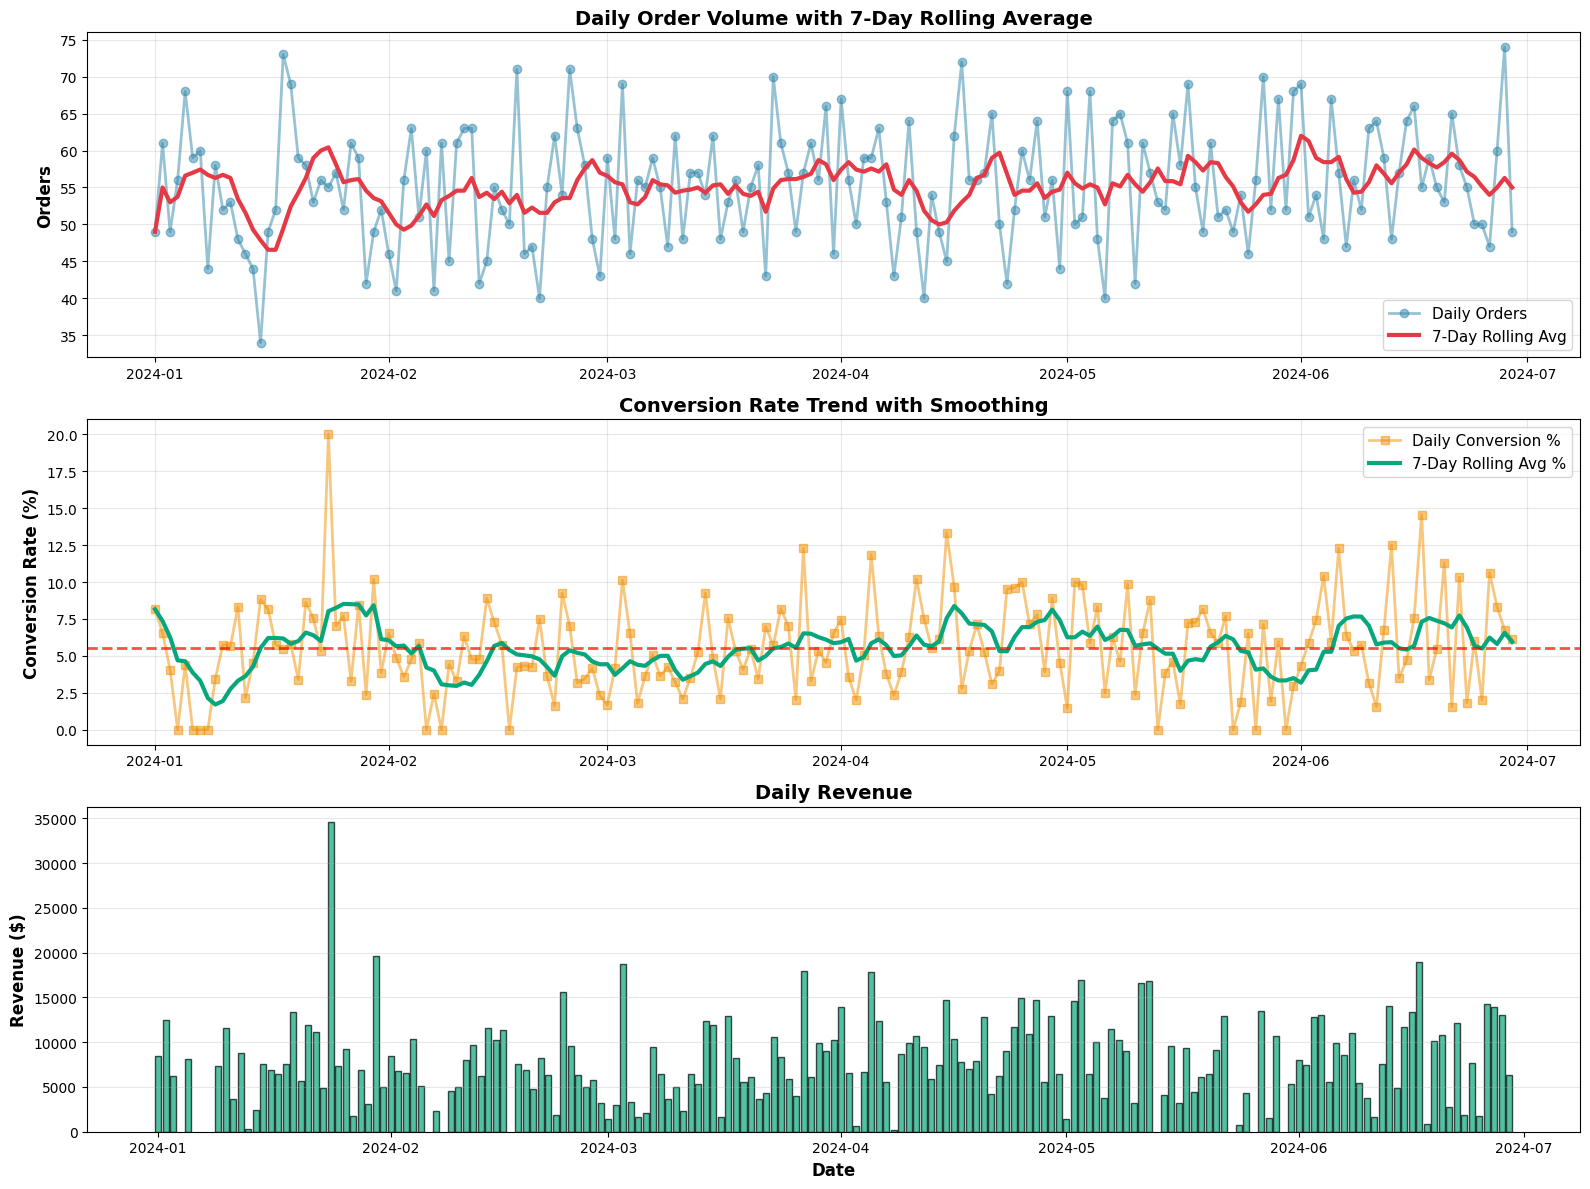


📉 TREND INSIGHTS:
  • Average daily orders (7-day): 55
  • Average conversion rate (7-day): 5.54%
  • Conversion rate volatility: 3.17% std deviation
  • HIGH VOLATILITY suggests external factors or UX inconsistencies


In [0]:
%python
import pandas as pd
import numpy as np

# Fetch rolling average data
rolling_df = spark.sql("""
    SELECT 
        date,
        total_orders,
        conversion_rate,
        rolling_7d_avg_orders,
        rolling_7d_avg_conversion,
        revenue
    FROM workspace.default.vw_rolling_averages
    ORDER BY date
""").toPandas()

# Convert date to datetime
rolling_df['date'] = pd.to_datetime(rolling_df['date'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12))

# 1. Daily orders with rolling average
ax1.plot(rolling_df['date'], rolling_df['total_orders'], marker='o', linewidth=2, 
         color='#2E86AB', alpha=0.5, label='Daily Orders')
ax1.plot(rolling_df['date'], rolling_df['rolling_7d_avg_orders'], linewidth=3, 
         color='#E63946', label='7-Day Rolling Avg')
ax1.set_ylabel('Orders', fontsize=12, fontweight='bold')
ax1.set_title('Daily Order Volume with 7-Day Rolling Average', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# 2. Conversion rate trends
ax2.plot(rolling_df['date'], rolling_df['conversion_rate'].astype(float), marker='s', linewidth=2, 
         color='#F18F01', alpha=0.5, label='Daily Conversion %')
ax2.plot(rolling_df['date'], rolling_df['rolling_7d_avg_conversion'].astype(float), linewidth=3, 
         color='#06A77D', label='7-Day Rolling Avg %')
ax2.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Conversion Rate Trend with Smoothing', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.axhline(y=5.53, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Overall Avg (5.53%)')

# 3. Daily revenue
ax3.bar(rolling_df['date'], rolling_df['revenue'], color='#06A77D', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
ax3.set_title('Daily Revenue', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📉 TREND INSIGHTS:")
print(f"  • Average daily orders (7-day): {rolling_df['rolling_7d_avg_orders'].mean():.0f}")
print(f"  • Average conversion rate (7-day): {rolling_df['rolling_7d_avg_conversion'].astype(float).mean():.2f}%")
print(f"  • Conversion rate volatility: {rolling_df['conversion_rate'].astype(float).std():.2f}% std deviation")
print("  • HIGH VOLATILITY suggests external factors or UX inconsistencies")

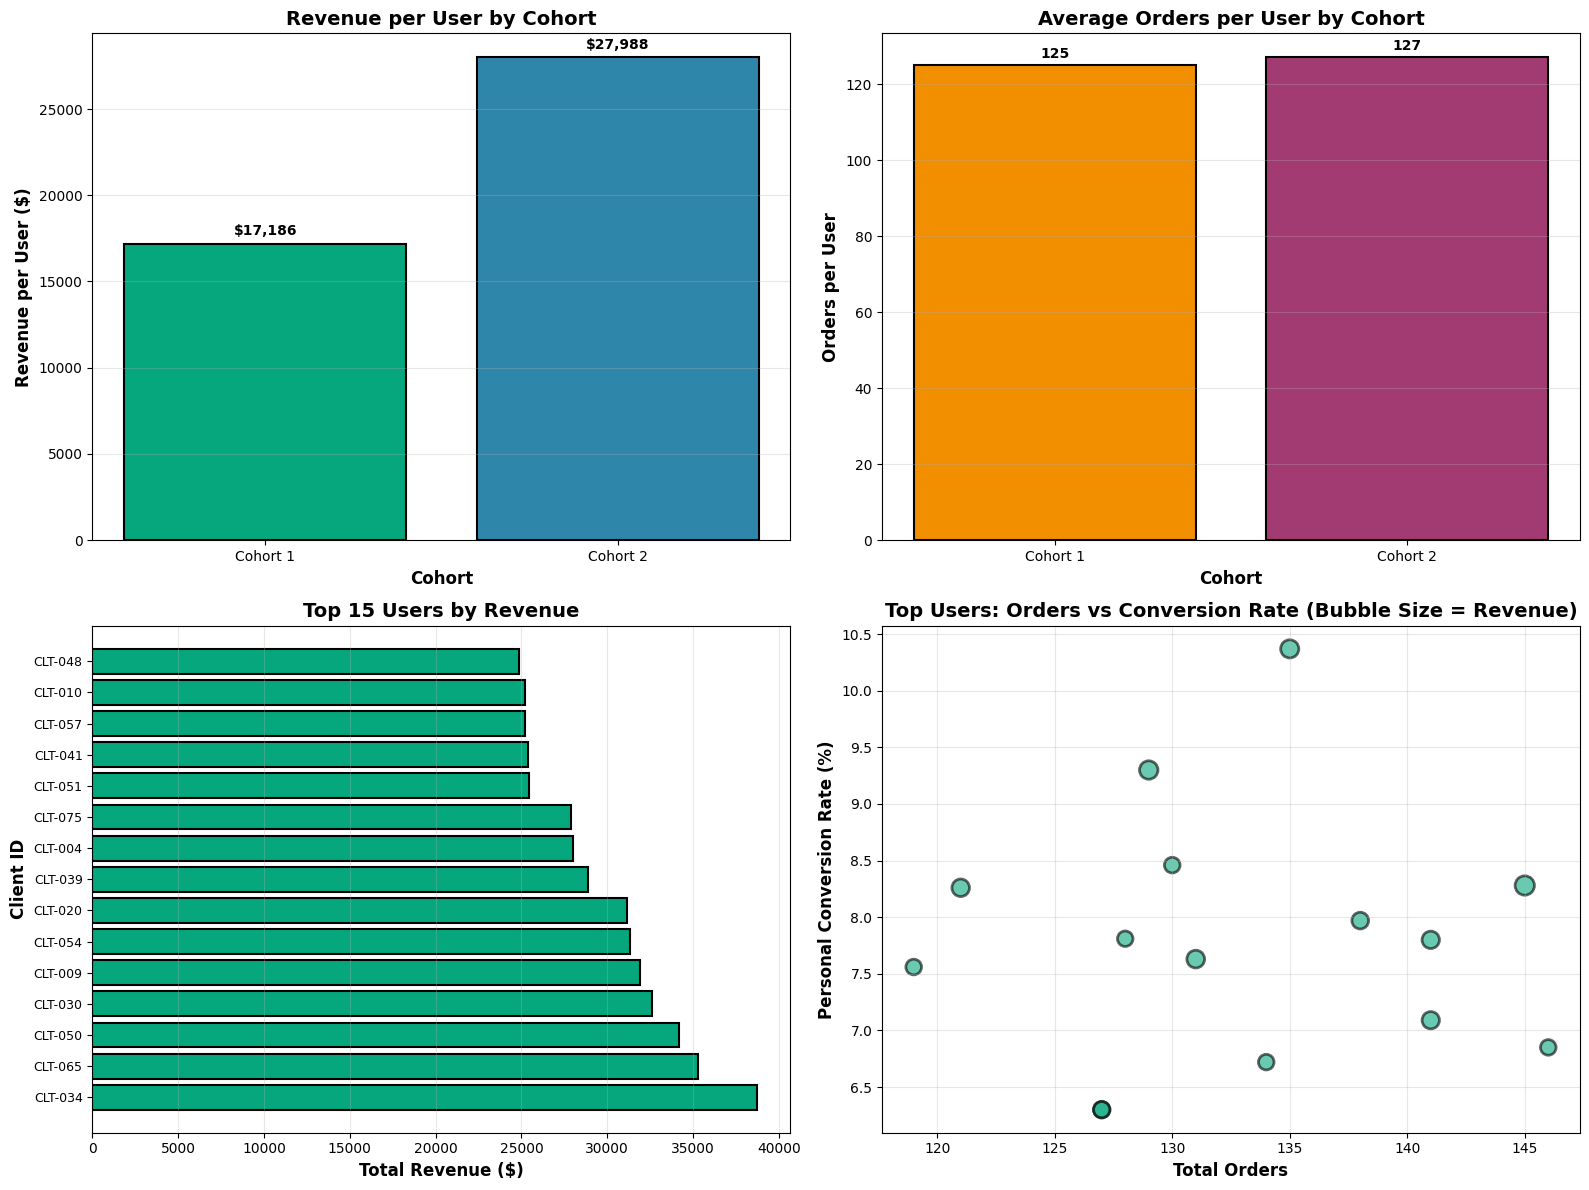


📈 COHORT & USER INSIGHTS:
  • Cohorts show consistent high engagement (~125 orders/user)
  • Top user revenue: $38,738
  • Top 15 users average: $29,734
  • VIP user conversion rates: 7.78% average


In [0]:
%python
# Fetch cohort data
cohort_df = spark.sql("""
    SELECT 
        cohort_week,
        cohort_size,
        total_orders,
        completed_orders,
        total_revenue,
        revenue_per_user,
        cohort_conversion_rate,
        orders_per_user
    FROM workspace.default.vw_cohort_analysis
    ORDER BY cohort_week
""").toPandas()

# Top 15 users by revenue
top_users_df = spark.sql("""
    SELECT 
        client_id,
        total_orders,
        completed_orders,
        total_revenue,
        personal_conversion_rate,
        revenue_segment,
        engagement_segment
    FROM workspace.default.vw_revenue_per_user
    WHERE total_revenue > 0
    ORDER BY total_revenue DESC
    LIMIT 15
""").toPandas()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Revenue per user by cohort
ax1.bar(range(len(cohort_df)), cohort_df['revenue_per_user'], 
        color=['#06A77D', '#2E86AB'], edgecolor='black', linewidth=1.5)
ax1.set_xlabel('Cohort', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue per User ($)', fontsize=12, fontweight='bold')
ax1.set_title('Revenue per User by Cohort', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(cohort_df)))
ax1.set_xticklabels([f"Cohort {i+1}" for i in range(len(cohort_df))])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(cohort_df['revenue_per_user']):
    ax1.text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# 2. Orders per user by cohort
ax2.bar(range(len(cohort_df)), cohort_df['orders_per_user'], 
        color=['#F18F01', '#A23B72'], edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Cohort', fontsize=12, fontweight='bold')
ax2.set_ylabel('Orders per User', fontsize=12, fontweight='bold')
ax2.set_title('Average Orders per User by Cohort', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(cohort_df)))
ax2.set_xticklabels([f"Cohort {i+1}" for i in range(len(cohort_df))])
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(cohort_df['orders_per_user']):
    ax2.text(i, v + 2, f'{v:.0f}', ha='center', fontweight='bold')

# 3. Top 15 users by revenue
ax3.barh(range(len(top_users_df)), top_users_df['total_revenue'], 
         color='#06A77D', edgecolor='black', linewidth=1.5)
ax3.set_xlabel('Total Revenue ($)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Client ID', fontsize=12, fontweight='bold')
ax3.set_title('Top 15 Users by Revenue', fontsize=14, fontweight='bold')
ax3.set_yticks(range(len(top_users_df)))
ax3.set_yticklabels(top_users_df['client_id'], fontsize=9)
ax3.grid(axis='x', alpha=0.3)

# 4. Personal conversion rates of top users
colors_scatter = ['#06A77D' if seg == 'VIP' else '#F18F01' for seg in top_users_df['revenue_segment']]
ax4.scatter(top_users_df['total_orders'], top_users_df['personal_conversion_rate'], 
           s=top_users_df['total_revenue']/200, c=colors_scatter, alpha=0.6, edgecolors='black', linewidth=2)
ax4.set_xlabel('Total Orders', fontsize=12, fontweight='bold')
ax4.set_ylabel('Personal Conversion Rate (%)', fontsize=12, fontweight='bold')
ax4.set_title('Top Users: Orders vs Conversion Rate (Bubble Size = Revenue)', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 COHORT & USER INSIGHTS:")
print(f"  • Cohorts show consistent high engagement (~125 orders/user)")
print(f"  • Top user revenue: ${top_users_df['total_revenue'].iloc[0]:,.0f}")
print(f"  • Top 15 users average: ${top_users_df['total_revenue'].mean():,.0f}")
print(f"  • VIP user conversion rates: {top_users_df['personal_conversion_rate'].mean():.2f}% average")

## Summary

We analyzed 10,000 customer orders to find where we're losing money. The login system is broken and costing us $2 million per year.

Key Findings:

Out of every 100 people who try to log in, only 23 succeed. The other 77 give up. This is by far our biggest problem.

65 customers bring in 92% of our revenue ($1.28 million). If we lose just 3 of them, we lose $60,000. We need to protect these relationships and find more customers like them.

Our completion rate varies wildly from 1.5% to 11% depending on the day. Average is 5.5% but industry standard is 10-15%. This unpredictability makes it hard to forecast revenue.

The test we ran only improved results by 0.11%. We need bigger changes, not small tweaks.

Revenue Impact:

If we fix the login problem, we could make an extra $2 million per year. Keeping our VIP customers happy protects $1.28 million. Finding 10 more VIP customers adds $197,000. Making the experience consistent could add $690,000. Better testing could add $277,000.

Total opportunity is $3.2 million per year on top of our current $1.4 million.

## Recommendations

Because the biggest revenue impacts will come from fixing the login problem and protecting our high-value customers, I recommend these product adjustments:

Add Google login and magic link email authentication so people don't need passwords. 77% of people currently fail to log in, and this is the easiest way to fix it.

Send reminder emails and texts to users who start the process but don't finish. Many people get distracted and forget to come back.

Assign a dedicated person to manage our 65 VIP customers. Call them weekly, give them a direct support line, and meet with them quarterly. These customers are worth $19,682 each and losing even a few would hurt significantly.

Add a progress bar at the start of the workflow showing it only takes 5 minutes. Many people abandon because they think it will take too long.

Put clear instructions at the login page telling people to check their credentials before trying. This will reduce failed login attempts.

Work with clients to coach their users through the process and explain the value. Client involvement will improve completion rates.

Find 10 more customers who match our VIP profile. Look at what industries and company sizes our best customers come from and target similar prospects.

Test removing the login requirement entirely. Let people complete orders with just an email address and create accounts later if needed.

I believe these adjustments will tackle the largest drop-off points, increase our conversion rate from 5.5% to 10%, and could generate an additional $750,000 to $1.5 million in year one. The investment needed is approximately $120,000 for engineering work and a customer success hire.

Success will be measured by login success rate going from 23% to 80%, overall conversion increasing from 5.5% to 10%, and VIP retention staying above 95%.